# Plotting the duration of NPF events over the year:

This notebook generates Figures 3a) and 3b) showing the annual cycle of duration of NPF events, time of day break and time in which the event starts

## Data Source
Growth rate data from `GR_rate.dat` in the `Analysis/elected_bonds/NPF_events_DMPS_NAIS/GR_dfs/` folder. Radiation data i.e. `GHI_Radiation.dat` and `NYA_Radiation.dat` from `Analysis\Radiation` 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
from pvlib.location import Location
from pvlib.iotools import read_tmy3

from matplotlib.dates import DateFormatter
from pathlib import Path

plt.rcParams["font.family"] = 'monospace'

In [2]:
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

In [46]:
method_name='rate'

path=r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\GR_dfs'
print(path+'\\'+'GR_'+str(method_name)+'.dat')
df_NPF_for_hsplit = pd.read_csv(path+'\\'+'GR_'+str(method_name)+'.dat',
    index_col=0,parse_dates=True)

C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\selected_bonds\NPF_events_DMPS_NAIS\GR_dfs\GR_rate.dat


In [4]:
df_NPF_for_hsplit.head(2)

,diameters,date,slope,duration,starttime,startdate,endtime,datetime,ordinal,hour_ordinal,hour_in_day,minute_in_day,hour
datetimes,,,,,,,,,,,,,
2022-06-14 03:30:00,3.770083e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:30:00,738320,0,3,30,3.50
2022-06-14 03:45:00,3.934428e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:45:00,738320,0,3,45,3.75


In [5]:
df_duration = df_NPF_for_hsplit.groupby('date')['duration'].mean().to_frame()
df_duration.index = pd.to_datetime(df_duration.index)
df_duration['month'] = df_duration.index.month

In [6]:
quantile10 = df_duration['duration'].quantile(.1)
print(quantile10)
quantile25 = df_duration['duration'].quantile(.25)
print(quantile25)

3.4000000000000004
6.0


In [7]:
def q75(x):
    return x.quantile(0.75)
def q50(x):
    return x.quantile(0.5)
def q25(x):
    return x.quantile(0.25)

In [8]:
df_duration_M = df_duration.resample('ME').median()
df_duration_M = df_duration.groupby('month').median()
df_duration_M = df_duration.groupby('month').mean()
df_duration_M = df_duration.groupby('month').agg({'duration': [q50, q25, q75, 'mean']})
df_duration_M.columns = ['q50', 'q25', 'q75', 'mean']

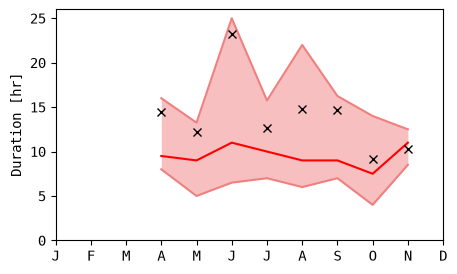

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
x=df_duration_M.index

ax.plot(df_duration_M.index, df_duration_M['q75'].values, color='lightcoral')
ax.plot(df_duration_M.index, df_duration_M['q50'].values, color='r')
ax.plot(df_duration_M.index, df_duration_M['q25'].values, color='lightcoral')
ax.plot(df_duration_M.index, df_duration_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_duration_M['q50'], df_duration_M['q75'], alpha=.5, linewidth=0, color='lightcoral')
ax.fill_between(x, df_duration_M['q25'], df_duration_M['q50'], alpha=.5, linewidth=0, color='lightcoral')

ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
ax.set_ylim(0, 26)
ax.set_ylabel('Duration [hr]')

plt.show()

In [10]:
 df_NPF_for_hsplit.head(2)

,diameters,date,slope,duration,starttime,startdate,endtime,datetime,ordinal,hour_ordinal,hour_in_day,minute_in_day,hour
datetimes,,,,,,,,,,,,,
2022-06-14 03:30:00,3.770083e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:30:00,738320,0,3,30,3.50
2022-06-14 03:45:00,3.934428e-09,2022-06-14,6.068124e-10,11.0,2022-06-14 03:30:00,2022-06-14,2022-06-14 15:00:00,2022-06-14 03:45:00,738320,0,3,45,3.75


In [11]:
grouped =  df_NPF_for_hsplit.groupby('date')
dataframes = [group for _, group in grouped]

In [12]:
dataframes[0].head(2)

,diameters,date,slope,duration,starttime,startdate,endtime,datetime,ordinal,hour_ordinal,hour_in_day,minute_in_day,hour
datetimes,,,,,,,,,,,,,
2022-04-18 11:15:00,6.521878e-09,2022-04-18,1.722246e-09,5.0,2022-04-18 11:15:00,2022-04-18,2022-04-18 17:00:00,2022-04-18 11:15:00,738263,0,11,15,11.25
2022-04-18 11:30:00,6.977280e-09,2022-04-18,1.722246e-09,5.0,2022-04-18 11:15:00,2022-04-18,2022-04-18 17:00:00,2022-04-18 11:30:00,738263,0,11,30,11.50


In [13]:
dataframes[0]['starttime'].iloc[0] #.head(2)

'2022-04-18 11:15:00'

In [14]:
dict_date_to_start = {}
for i in range(len(dataframes)):
    print(dataframes[i]['starttime'].iloc[0])
    datetime_value = pd.to_datetime(dataframes[i]['starttime'].iloc[0]).time()
    print(datetime_value)
    dict_date_to_start[str(pd.to_datetime(dataframes[i]['starttime'].iloc[0]).date())] = datetime_value
    str_time = datetime.datetime.strptime(str(datetime_value), "%H:%M:%S").strftime("%H:%M")
    print(str_time)

2022-04-18 11:15:00
11:15:00
11:15
2022-04-21 08:00:00
08:00:00
08:00
2022-04-23 07:45:00
07:45:00
07:45
2022-04-24 13:00:00
13:00:00
13:00
2022-04-28 03:45:00
03:45:00
03:45
2022-04-29 12:15:00
12:15:00
12:15
2022-05-02 09:45:00
09:45:00
09:45
2022-05-03 05:00:00
05:00:00
05:00
2022-05-04 09:30:00
09:30:00
09:30
2022-05-05 08:00:00
08:00:00
08:00
2022-05-16 11:00:00
11:00:00
11:00
2022-05-17 08:30:00
08:30:00
08:30
2022-05-19 10:00:00
10:00:00
10:00
2022-05-20 07:15:00
07:15:00
07:15
2022-05-22 12:45:00
12:45:00
12:45
2022-05-30 06:15:00
06:15:00
06:15
2022-06-02 07:45:00
07:45:00
07:45
2022-06-05 11:45:00
11:45:00
11:45
2022-06-13 11:30:00
11:30:00
11:30
2022-06-14 03:30:00
03:30:00
03:30
2022-06-17 06:45:00
06:45:00
06:45
2022-06-24 20:15:00
20:15:00
20:15
2022-06-25 10:00:00
10:00:00
10:00
2022-07-02 11:15:00
11:15:00
11:15
2022-07-09 07:30:00
07:30:00
07:30
2022-07-17 10:00:00
10:00:00
10:00
2022-07-18 14:30:00
14:30:00
14:30
2022-07-19 15:15:00
15:15:00
15:15
2022-07-22 13:45:00


In [ ]:
df_starttime = pd.DataFrame(dict_date_to_start.items(), columns=['date', 'time'])
df_starttime['hour'] = df_starttime['time'].astype(str).str[:2]
df_starttime['minute'] = df_starttime['time'].astype(str).str[3:5]
df_starttime['time_decimal'] = df_starttime['hour'].astype(float)+df_starttime['minute'].astype(float)/60
df_starttime = df_starttime.set_index('date')
df_starttime.index = pd.to_datetime(df_starttime.index)
df_starttime['month'] = df_starttime.index.month

In [16]:
df_starttime.head(2)

,time,hour,minute,time_decimal,month
date,,,,,
2022-04-18,11:15:00,11,15,11.25,4
2022-04-21,08:00:00,08,00,8.00,4


In [17]:
df_starttime_M = df_starttime.groupby('month').agg({'time_decimal': [q50, q25, q75, 'mean']})
df_starttime_M.columns = ['q50', 'q25', 'q75', 'mean']

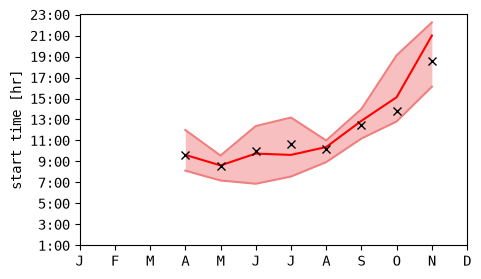

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))
x=df_starttime_M.index

ax.plot(x, df_starttime_M['q75'].values, color='lightcoral')
ax.plot(x, df_starttime_M['q50'].values, color='r')
ax.plot(x, df_starttime_M['q25'].values, color='lightcoral')
ax.plot(x, df_starttime_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_starttime_M['q50'], df_starttime_M['q75'], alpha=.5, linewidth=0, color='lightcoral')
ax.fill_between(x, df_starttime_M['q25'], df_starttime_M['q50'], alpha=.5, linewidth=0, color='lightcoral')

ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
ax.set_yticks(np.arange(1,25, 2), ['1:00','2:00','3:00','4:00','5:00','6:00','7:00',
                                    '8:00', '9:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00',
                                    '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00', '24:00'][::2])
#ax.set_ylim(0, 30)
ax.set_ylabel('start time [hr]')
plt.show()

# Day break: 

In [19]:
latitude = 78.922700
longitude = 11.927300

tus = Location(latitude=latitude, longitude=longitude, tz='UTC', altitude=474, name=None)
times = pd.date_range(start='2022-04-01', end='2024-10-04', freq='1min', tz=tus.tz)

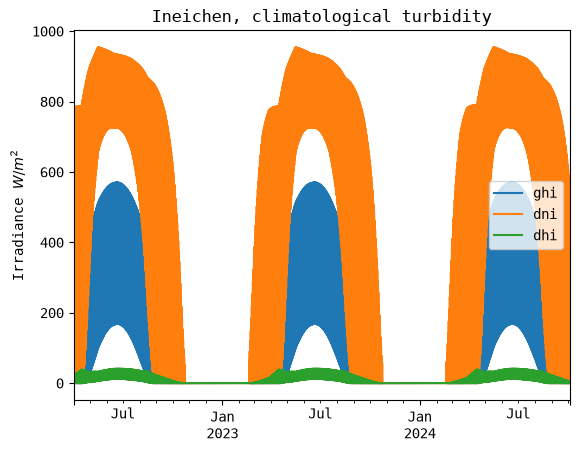

In [20]:
cs = tus.get_clearsky(times)  # ineichen with climatology table by default
cs.plot();
plt.ylabel('Irradiance $W/m^2$');
plt.title('Ineichen, climatological turbidity');
plt.show()

In [21]:
cs.index = pd.to_datetime(cs.index)
df = cs.copy()
df.index = df.index.tz_convert(None)

In [22]:
def fancy(ax, fontsize=20, spines=['top','bottom','left','right'], alpha=0.5):    
    # thickning the axes spines
    for axis in spines:
        ax.spines[axis].set_linewidth(2)
        ax.spines[axis].set_color('k')        
    # set the fontsize for all your ticks    
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)        
    # properties of the ticks
    ax.tick_params(direction='out', length=8, width=2, pad=10, bottom=True, top=False, left=True, right=False, color='k')    
    # add a grid to the plot
    ax.grid(True, alpha=alpha)  

def plot_radiation(df, variable, date=None, fontsize=12, varlabel=None, ymax=None, date_formater="%H", ax=None):
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(15,5))
        single_plot = True

    if varlabel == None:
        varlabel = str(variable)
    date_form = DateFormatter(date_formater)
    ax.xaxis.set_major_formatter(date_form)

    if date is not None:
        plt.xlim(pd.to_datetime(date), pd.to_datetime(date)+timedelta(days=1))   
    fancy(ax, fontsize=fontsize) 
    ax.set_ylabel(varlabel, fontsize=fontsize)
       
    time = df.index
    var = df[variable].values
    
    if ymax is not None:
        ax.set_ylim(0, ymax)
    
    ax.plot(time, var, 'o-', c='r', ms=3)
    

    if single_plot == True:
        plt.show()
        return fig

    if single_plot == False:
        return ax

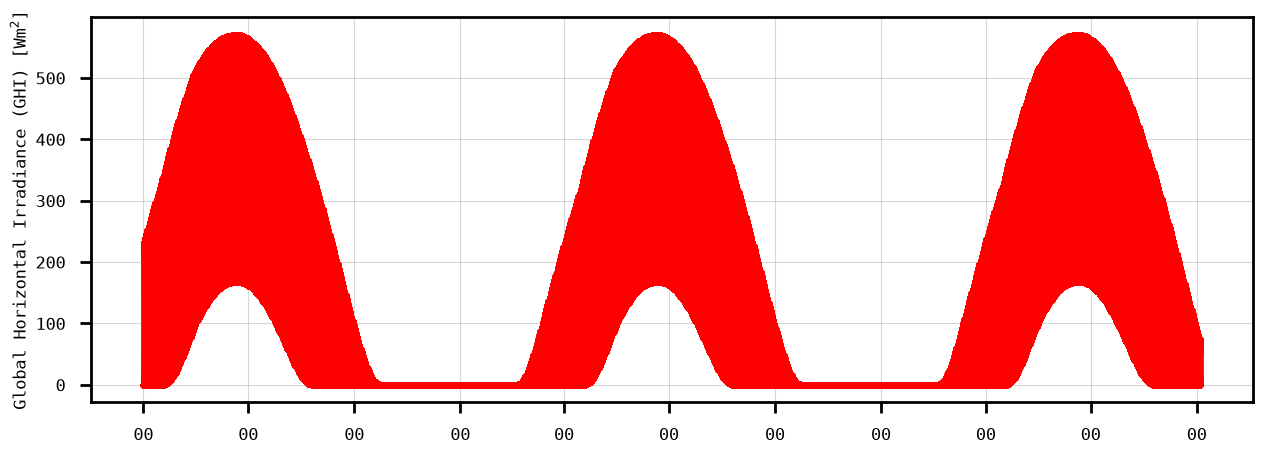

In [23]:
fig = plot_radiation(df, variable='ghi', varlabel='Global Horizontal Irradiance (GHI) [Wm$^{2}$]',
                    date_formater='%M')

In [24]:
loadpath_radiation = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Radiation'

df.to_csv(loadpath_radiation + r'\GHI_Radiation.dat', index=True)
df_rad = pd.read_csv(loadpath_radiation + r'\NYA_Radiation.dat', index_col=0, 
                    parse_dates=True)

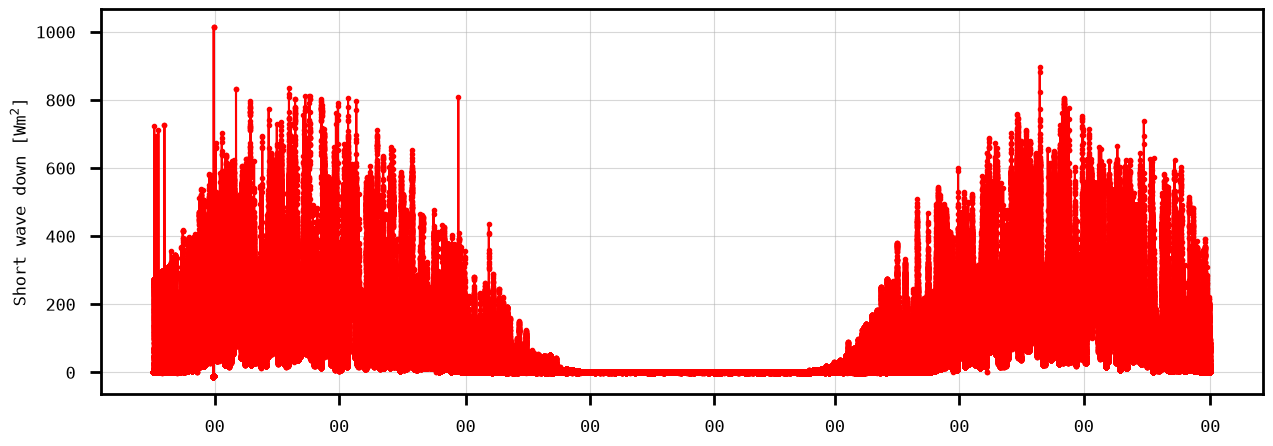

In [25]:
fig = plot_radiation(df_rad, variable='SWD [W/m**2]', varlabel='Short wave down [Wm$^{2}$]')

In [26]:
df_rad['total_down'] = df_rad['SWD [W/m**2]'] + df_rad['LWD [W/m**2]']

In [27]:
def plot_radiation(df, df_rad, variable, date=None, fontsize=12, varlabel=None, ymax=None, 
                   both_LWD_SWD=False, SWD=True, ax=None):
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(15,5))
        single_plot = True

    if varlabel == None:
        varlabel = str(variable)
    date_form = DateFormatter("%Y-%m")
    ax.xaxis.set_major_formatter(date_form)

    if date is not None:
        plt.xlim(pd.to_datetime(date), pd.to_datetime(date)+timedelta(days=1))   
    fancy(ax, fontsize=fontsize) 
    ax.set_ylabel(varlabel, fontsize=fontsize)
       
    time = df.index
    var = df[variable].values
    
    if ymax is not None:
        ax.set_ylim(0, ymax)
    
    ax.plot(time, var, 'o', c='r', ms=1, alpha=.5, 
            label='Global Horizontal Irradiance: \nDirect Normal Irradiance (DNI) x cos(solar zenith angle) + Diffused Horizontal Irradiance (DHI)')
    
    if both_LWD_SWD == True:
        ax.plot(df_rad.index, df_rad['total_down'], 'o', ms=1, alpha=.5, mec='b', mfc='None', 
                label='SWD + LWD [W/m**2]')
    if SWD == True:
        ax.plot(df_rad.index, df_rad['SWD [W/m**2]'], 'o', ms=1, alpha=.5, mec='b', mfc='None', 
            label='SWD [W/m**2]')

    ax.legend(markerscale=10, loc=2)
    
    if single_plot == True:
        plt.show()
        return fig

    if single_plot == False:
        return ax

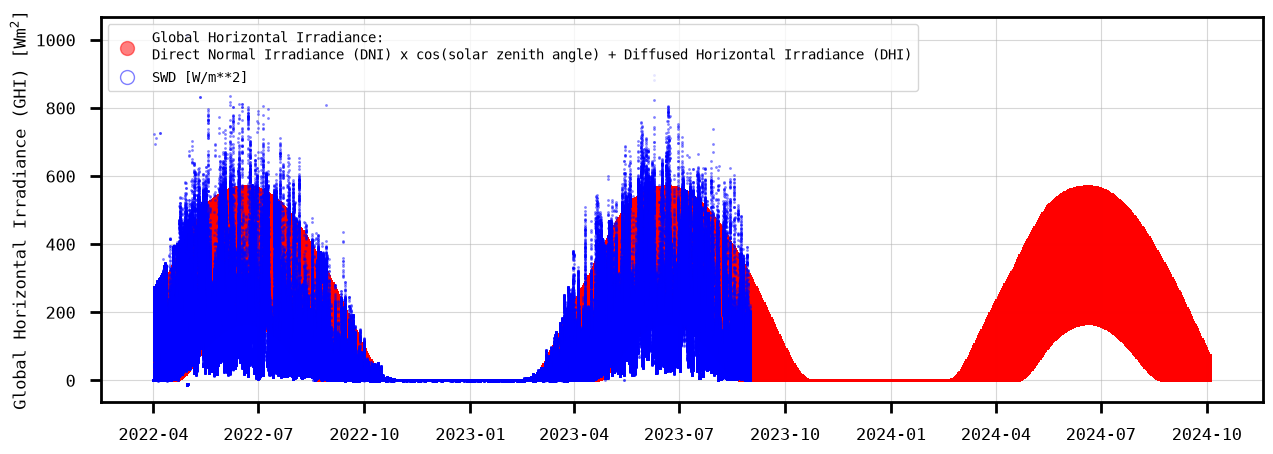

In [28]:
fig = plot_radiation(df, df_rad, variable='ghi', 
                     varlabel='Global Horizontal Irradiance (GHI) [Wm$^{2}$]')

In [29]:
df_merge = df.copy() #pd.merge(df_rad, df, left_index=True, right_index=True)

df_merge['Day_of_Year'] = df_merge.index.dayofyear
df_merge['year'] = df_merge.index.year - 2022

df_merge['year_days'] = df_merge['year']*365.25
df_merge['Day_of_Years'] = df_merge['year_days']+df_merge['Day_of_Year']
df_merge['Day_of_Years'] = df_merge['Day_of_Years'].astype(int)

In [30]:
def plot_radiation_day(df, variable, date=None, fontsize=12, varlabel=None, ymax=None, 
                   both_LWD_SWD=False, SWD=True, title='', ax=None):
    single_plot = False
    if ax == None:
        fig, ax = plt.subplots(figsize=(15,5))
        single_plot = True

    if varlabel == None:
        varlabel = str(variable)
    date_form = DateFormatter("%H")
    ax.xaxis.set_major_formatter(date_form)

    if date is not None:
        plt.xlim(pd.to_datetime(date), pd.to_datetime(date)+timedelta(days=1))   
    fancy(ax, fontsize=fontsize) 
    ax.set_ylabel(varlabel, fontsize=fontsize)
       
    time = df.index
    var = df[variable].values
    
    if ymax is not None:
        ax.set_ylim(0, ymax)
    
    ax.plot(time, var, 'o', c='r', ms=1, alpha=.5, 
            label='Global Horizontal Irradiance: \nDirect Normal Irradiance (DNI) x cos(solar zenith angle) + Diffused Horizontal Irradiance (DHI)')
    
    if both_LWD_SWD == True:
        ax.plot(df.index, df['total_down'], 'o', ms=1, alpha=.5, mec='b', mfc='None', 
                label='SWD + LWD [W/m**2]')
    if SWD == True:
        ax.plot(df.index, df['SWD [W/m**2]'], 'o', ms=1, alpha=.5, mec='b', mfc='None', 
            label='SWD [W/m**2]')

    ax.legend(markerscale=10, loc=2)
    ax.set_title(title, loc='left')
        
    if single_plot == True:
        plt.show()
        return fig

    if single_plot == False:
        return ax

In [31]:
dict_day_to_ghi = {}
for dayofyear in df_merge['Day_of_Years'].unique():
    df_day = df_merge[df_merge['Day_of_Years'] == dayofyear]
    try:
        day_ghi_daytime = df_day[df_day['ghi'] > 0].index[0]
        date = day_ghi_daytime.date()
        dict_day_to_ghi[date] = pd.to_datetime(day_ghi_daytime).time()
    except:
        pass

In [32]:
df_daybreak = pd.DataFrame(dict_day_to_ghi.items(), columns=['date', 'daybreak'])

In [33]:
df_daybreak.head(2)

,date,daybreak
0,2022-04-01,03:30:00
1,2022-04-02,03:20:00


In [34]:
def add_decimal_hr(df):
    df['hour'] = df['daybreak'].astype(str).str[:2]
    df['minute'] = df['daybreak'].astype(str).str[3:5]
    df['time_decimal'] = df['hour'].astype(float)+df['minute'].astype(float)/60
    df = df.set_index('date')
    df.index = pd.to_datetime(df.index)
    df['month'] = df.index.month
    return df

In [35]:
df_daybreak = add_decimal_hr(df_daybreak)

In [36]:
def q75(x):
    return x.quantile(0.75)
def q50(x):
    return x.quantile(0.5)
def q25(x):
    return x.quantile(0.25)

In [37]:
df_daybreak_M = df_daybreak.groupby('month').agg({'time_decimal': [q50, q25, q75, 'mean']})
df_daybreak_M.columns = ['q50', 'q25', 'q75', 'mean']

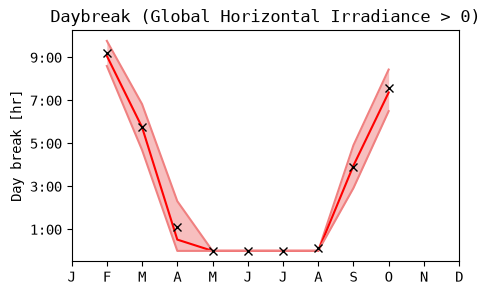

In [38]:
fig, ax = plt.subplots(figsize=(5, 3))
x=df_daybreak_M.index

ax.plot(x, df_daybreak_M['q75'].values, color='lightcoral')
ax.plot(x, df_daybreak_M['q50'].values, color='r')
ax.plot(x, df_daybreak_M['q25'].values, color='lightcoral')
ax.plot(x, df_daybreak_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_daybreak_M['q50'], df_daybreak_M['q75'], alpha=.5, linewidth=0, color='lightcoral')
ax.fill_between(x, df_daybreak_M['q25'], df_daybreak_M['q50'], alpha=.5, linewidth=0, color='lightcoral')

ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
ax.set_yticks(np.arange(1,10, 2), ['1:00','2:00','3:00','4:00','5:00','6:00','7:00',
                                    '8:00', '9:00', '10:00'][::2])
#ax.set_ylim(0, 30)
ax.set_title('Daybreak (Global Horizontal Irradiance > 0)')
ax.set_ylabel('Day break [hr]')
plt.show()

In [39]:
df_daybreak = df_daybreak[['daybreak', 'time_decimal']].rename(columns={'daybreak':'daybreak_time', 
                                                          'time_decimal':'daybreak_time_decimal'})
df_starttime_daybreak = df_starttime.merge(df_daybreak[['daybreak_time', 'daybreak_time_decimal']], left_index=True, right_index=True)

df_starttime_daybreak = df_starttime_daybreak[['time', 'time_decimal', 'month', 'daybreak_time', 'daybreak_time_decimal']].copy()
df_starttime_daybreak['daybreak_time'] = df_starttime_daybreak['daybreak_time'].replace(datetime.time(0, 0), np.nan)
df_starttime_daybreak['daybreak_time_decimal'] = df_starttime_daybreak['daybreak_time_decimal'].replace(0, np.nan)

In [40]:
df_starttime_daybreak.head(2)

,time,time_decimal,month,daybreak_time,daybreak_time_decimal
date,,,,,
2022-04-18,11:15:00,11.25,4,NaN,NaN
2022-04-21,08:00:00,8.00,4,NaN,NaN


In [41]:
df_startitme_M = df_starttime_daybreak.groupby('month').agg({'time_decimal': [q50, q25, q75, 'mean']})
df_starttime_M.columns = ['q50', 'q25', 'q75', 'mean']

df_daybreak_M = df_starttime_daybreak.groupby('month').agg({'daybreak_time_decimal': [q50, q25, q75, 'mean']})
df_daybreak_M.columns = ['q50', 'q25', 'q75', 'mean']

In [42]:
df_daybreak_M

,q50,q25,q75,mean
month,,,,
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,0.766667,0.620833,1.100000,0.811111
9,3.816667,3.220833,4.791667,3.862500
10,7.125000,6.779167,7.766667,7.420833


In [43]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

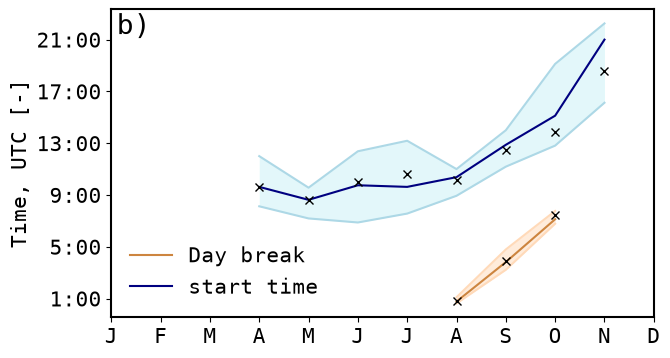

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_3b.jpeg


In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
x=df_daybreak_M.index

#blue #0072B2 for duration, 

ax.plot(x, df_daybreak_M['q75'].values, color='peachpuff')
ax.plot(x, df_daybreak_M['q50'].values, color='peru', label='Day break')
ax.plot(x, df_daybreak_M['q25'].values, color='peachpuff')
ax.plot(x, df_daybreak_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_daybreak_M['q50'], df_daybreak_M['q75'], alpha=.5, linewidth=0, color='peachpuff')
ax.fill_between(x, df_daybreak_M['q25'], df_daybreak_M['q50'], alpha=.5, linewidth=0, color='peachpuff')

x=df_starttime_M.index

dark_blue = '#000080'
light_blue = '#ADD8E6'
even_lighter_blue = '#E0F7FA'

ax.plot(x, df_starttime_M['q75'].values, color=light_blue)
ax.plot(x, df_starttime_M['q50'].values, color=dark_blue, label='start time')
ax.plot(x, df_starttime_M['q25'].values, color=light_blue)
ax.plot(x, df_starttime_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_starttime_M['q50'], df_starttime_M['q75'], alpha=.9, linewidth=0, color=even_lighter_blue)
ax.fill_between(x, df_starttime_M['q25'], df_starttime_M['q50'], alpha=.9, linewidth=0, color=even_lighter_blue)

ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
ax.set_yticks(np.arange(1,25, 4), ['1:00','2:00','3:00','4:00','5:00','6:00','7:00',
                                    '8:00', '9:00', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00',
                                    '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00', '24:00'][::4])
#ax.set_ylim(0, 30)
#ax.set_ylim(0, 30)
#ax.set_title('Daybreak (Global Horizontal Irradiance > 0)')
ax.text(0.01, 0.92, 'b)', transform=ax.transAxes, fontsize=20)
ax.legend(loc=3, frameon=False, fontsize=15)
ax.set_ylabel('Time, UTC [-]', fontsize=15)

ax.tick_params(axis="both", which="major", labelsize=15)
ax.tick_params(axis="both", which="minor", labelsize=15)


for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)

plt.show()

output_figure = plots_outpath / 'Figure_3b.jpeg'
save_plot(fig, output_figure)

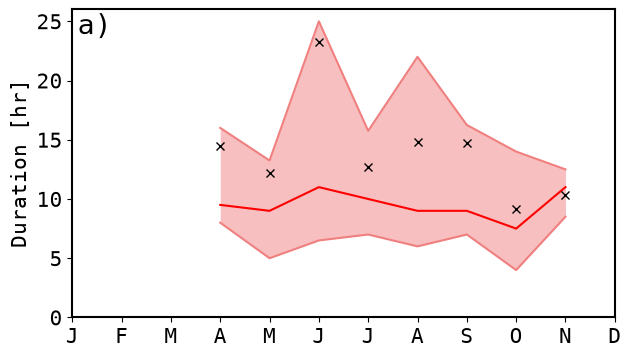

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_3a.jpeg


In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
x=df_duration_M.index

ax.plot(df_duration_M.index, df_duration_M['q75'].values, color='lightcoral')
ax.plot(df_duration_M.index, df_duration_M['q50'].values, color='r')
ax.plot(df_duration_M.index, df_duration_M['q25'].values, color='lightcoral')
ax.plot(df_duration_M.index, df_duration_M['mean'].values, 'x', c='k')

ax.fill_between(x, df_duration_M['q50'], df_duration_M['q75'], alpha=.5, linewidth=0, color='lightcoral')
ax.fill_between(x, df_duration_M['q25'], df_duration_M['q50'], alpha=.5, linewidth=0, color='lightcoral')

ax.set_xticks(np.arange(1,13, 1), ['J','F','M','A','M','J','J', 'A', 'S', 'O', 'N', 'D'])
ax.set_ylim(0, 26)
ax.set_ylabel('Duration [hr]', fontsize=15)

ax.tick_params(axis="both", which="major", labelsize=15)
ax.tick_params(axis="both", which="minor", labelsize=15)

ax.text(0.01, 0.92, 'a)', transform=ax.transAxes, fontsize=20)
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(1.5)

plt.show()

output_figure = plots_outpath / 'Figure_3a.jpeg'
save_plot(fig, output_figure)